In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import pytensor.tensor as pt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Algorithm

In [ ]:
def metropolis_hastings(log_target, x0, n_iter, proposal_sigma, rng=None):
  """

    Parameters
    ----------
    log_target: Function for the log of the target density at a given point.
    x0 : Initial point of Markov chain.
    n_iter : Number of iterations in chain.
    proposal_sigma : Standard deviation of the Gaussian random-walk proposal.
    rng : np.random.Generator, optional
        Random number generator (for reproducibility).

    Returns
    -------
    samples : np.ndarray, shape (n_iter,) or (n_iter, dim)
        The Markov chain, including the (unchanged) current state on
        rejected steps.
    accept_rate : float
        Fraction of proposals accepted.
    """

  x_current = np.atleast_1d(np.array(x0, dtype=float))
  dim = x_current.shape[0]

  samples = np.empty((n_iter, dim))
  log_p_current = log_target(x_current)
  n_accept = 0
  for i in range(n_iter):
        # Symmetric Gaussian random-walk proposal
        x_proposal = x_current + rng.normal(0.0, proposal_sigma, size=dim)
        log_p_proposal = log_target(x_proposal)

        # Acceptance probability (log scale), symmetric proposal -> plain
        # Metropolis ratio, no Hastings correction term needed.
        log_alpha = log_p_proposal - log_p_current

        if np.log(rng.uniform()) < log_alpha:
            x_current = x_proposal
            log_p_current = log_p_proposal
            n_accept += 1

        samples[i] = x_current

  accept_rate = n_accept / n_iter
  return samples.squeeze(), accept_rate

In [ ]:
# Example target: bimodal 1 dimensional Gaussian mixture

w1, mu1, sd1 = 0.5, 7.0, 3.0
w2, mu2, sd2 = 0.5, 17.0, 1.5

def log_target_bimodal(x):
    x = x[0]  # 1 dimension

    def norm_pdf(x, mu, sd):
        return np.exp(-0.5 * ((x - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))

    density = w1 * norm_pdf(x, mu1, sd1) + w2 * norm_pdf(x, mu2, sd2)
    return np.log(density + 1e-300)

def true_density(x):
    return (w1 * np.exp(-0.5 * ((x - mu1) / sd1) ** 2) / (sd1 * np.sqrt(2 * np.pi)) +
            w2 * np.exp(-0.5 * ((x - mu2) / sd2) ** 2) / (sd2 * np.sqrt(2 * np.pi)))

In [ ]:
rng = np.random.default_rng(seed=42)

n_iter = 50_000
burn_in = 5_000
proposal_sigma = 4.0

samples, accept_rate = metropolis_hastings(
    log_target_bimodal, x0=0.0, n_iter=n_iter,
    proposal_sigma=proposal_sigma, rng=rng
)

print(f"Acceptance rate: {accept_rate:.2%}")

samples_post_burnin = samples[burn_in:]

Acceptance rate: 58.82%


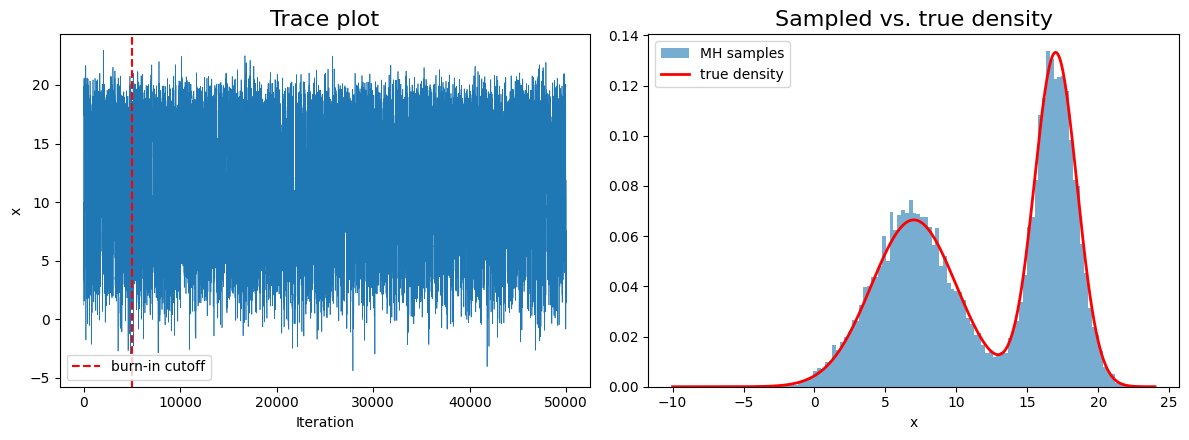

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(samples, lw=0.5)
axes[0].axvline(burn_in, color="red", linestyle="--", label="burn-in cutoff")
axes[0].set_title("Trace plot",fontsize=16)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("x")
axes[0].legend()

axes[1].hist(samples_post_burnin, bins=100, density=True,
              alpha=0.6, label="MH samples")
xs = np.linspace(-10, 24, 500)
axes[1].plot(xs, true_density(xs), "r-", lw=2, label="true density")
axes[1].set_title("Sampled vs. true density", fontsize=16)
axes[1].set_xlabel("x")
axes[1].legend()
plt.tight_layout()

# PyMC Reproduction

Output()

Shape validation failed: input_shape: (1, 45000), minimum_shape: (chains=2, draws=4)
/tmp/ipykernel_1331/2197328413.py:48: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for c in range(trace.posterior.dims["chain"]):


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x  12.052  5.515   2.675   19.472      0.066    0.022    7789.0   10596.0   

   r_hat  
x    NaN  
Mean acceptance rate: 37.21%


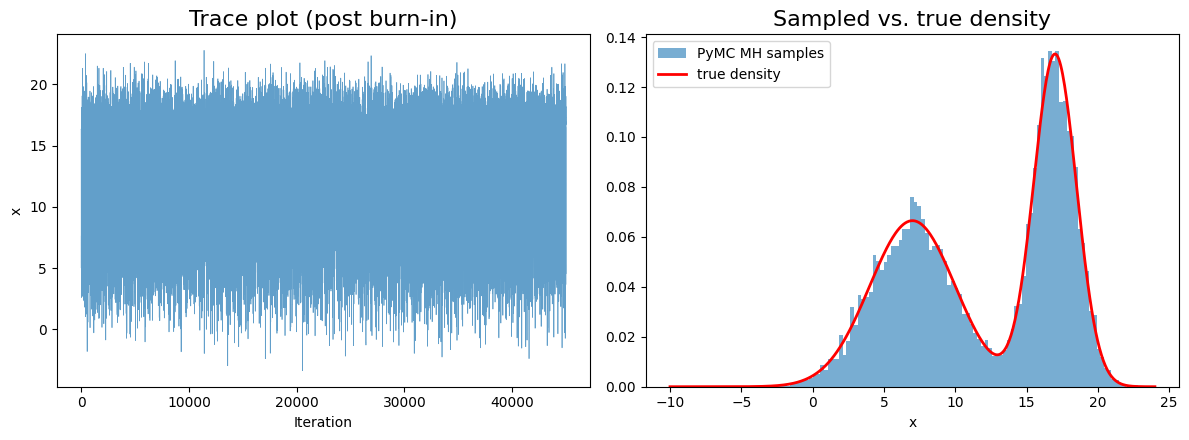

In [ ]:
# Define target density
def true_density(x):
    w1, mu1, sd1 = 0.5, 7.0, 3.0
    w2, mu2, sd2 = 0.5, 17.0, 1.5
    return (w1 * np.exp(-0.5 * ((x - mu1) / sd1) ** 2) / (sd1 * np.sqrt(2 * np.pi)) +
            w2 * np.exp(-0.5 * ((x - mu2) / sd2) ** 2) / (sd2 * np.sqrt(2 * np.pi)))



n_iter = 50_000
burn_in = 5_000

# PyMC Model
with pm.Model() as model:
    w = pt.as_tensor([0.5, 0.5])
    mu = pt.as_tensor([7.0, 17.0])
    sigma = pt.as_tensor([3.0, 1.5])

    x = pm.NormalMixture("x", w=w, mu=mu, sigma=sigma)

    step = pm.Metropolis(vars=[x], scaling=4.0)  # scaling = proposal_sigma
    trace = pm.sample(
        draws=n_iter-burn_in,
        tune=burn_in,
        step=step,
        chains=1,
        initvals={"x": 0.0},
        random_seed=42,
        progressbar=True,
    )

# Diagnostics
print(az.summary(trace, var_names=["x"]))

accept = trace.sample_stats["accepted"].values
print(f"Mean acceptance rate: {accept.mean():.2%}")

# Plot
samples = trace.posterior["x"].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for c in range(trace.posterior.dims["chain"]):
    axes[0].plot(trace.posterior["x"].values[c], lw=0.5, alpha=0.7)
axes[0].set_title("Trace plot (post burn-in)", fontsize=16)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("x")

axes[1].hist(samples, bins=100, density=True, alpha=0.6, label="PyMC MH samples")
xs = np.linspace(-10, 24, 500)
axes[1].plot(xs, true_density(xs), "r-", lw=2, label="true density")
axes[1].set_title("Sampled vs. true density", fontsize=16)
axes[1].set_xlabel("x")
axes[1].legend()

plt.tight_layout()

/tmp/ipykernel_1331/3958486693.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for c in range(trace.posterior.dims["chain"]):


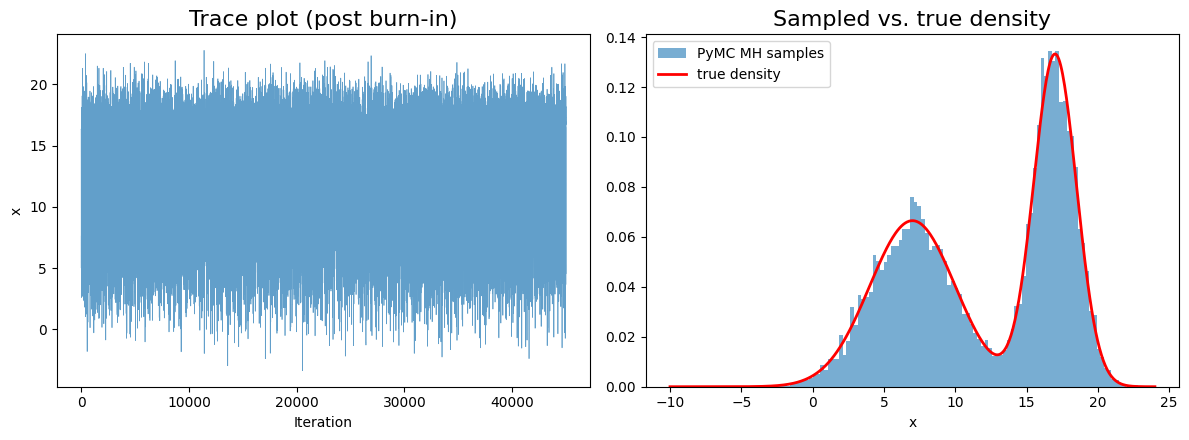

In [ ]:
samples = trace.posterior["x"].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for c in range(trace.posterior.dims["chain"]):
    axes[0].plot(trace.posterior["x"].values[c], lw=0.5, alpha=0.7)
axes[0].set_title("Trace plot (post burn-in)", fontsize=16)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("x")

axes[1].hist(samples, bins=100, density=True, alpha=0.6, label="PyMC MH samples")
xs = np.linspace(-10, 24, 500)
axes[1].plot(xs, true_density(xs), "r-", lw=2, label="true density")
axes[1].set_title("Sampled vs. true density", fontsize=16)
axes[1].set_xlabel("x")
axes[1].legend()

plt.tight_layout()

# DEMONSTRATIONS

DEMO 1: What the sampler actually does, step by step
iter  x_current  x_proposal  log_alpha log(u_random)  accept?
-------------------------------------------------------------
   0      0.000       0.004      0.000 -0.108     True
   1      0.004      -0.819     -0.677 -1.491     True
   2     -0.819      -2.183     -1.288 -0.135    False
   3     -0.819      -0.638      0.000 -0.197     True
   4     -0.638      -2.115     -1.374 -0.759    False
   5     -0.638       0.831      0.000 -1.279     True
   6      0.831       1.147      0.000 -0.810     True
   7      1.147       1.060     -0.057 -0.591     True
   8      1.060      -2.973     -3.565 -0.232    False
   9      1.060      -4.644     -5.572 -0.011    False
  10      1.060      -4.465     -5.343 -1.831    False
  11      1.060      -2.743     -3.313 -3.125    False
  12      1.060       1.530      0.000 -0.664     True
  13      1.530      -6.020     -7.756 -0.086    False
  14      1.530       1.384     -0.090 -0.665     Tru

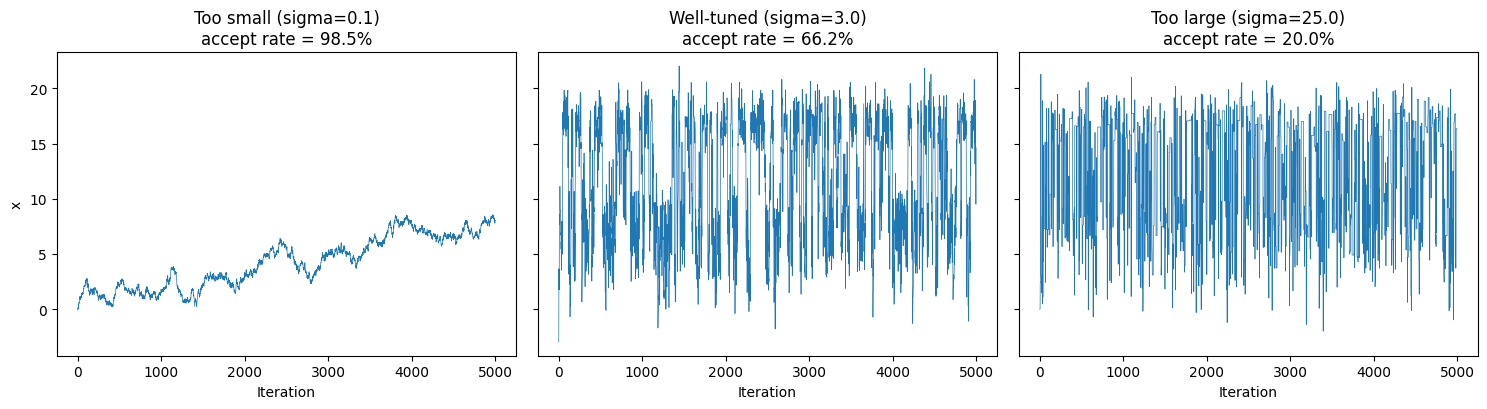

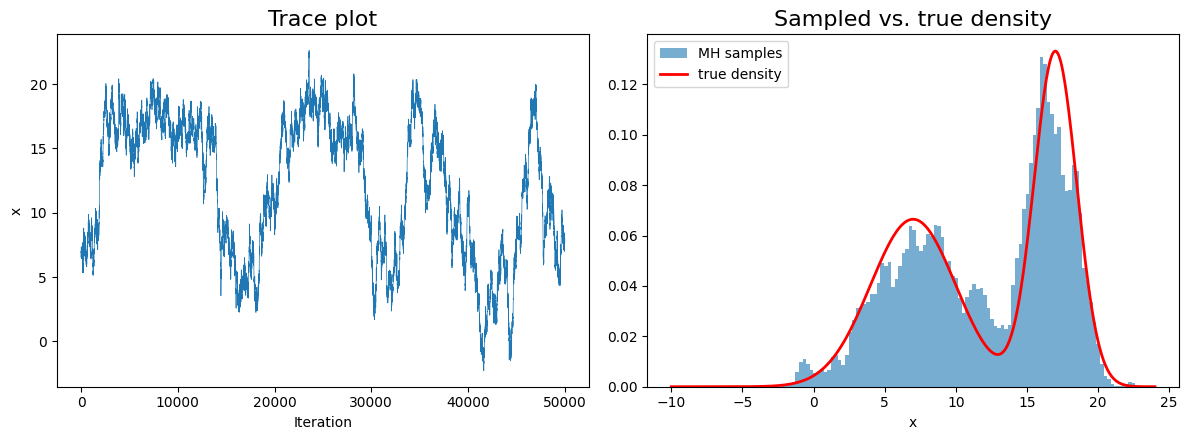

In [ ]:
# A version of the sampler that records per-step details
# ---------------------------------------------------------------------

def metropolis_hastings_verbose(log_target, x0, n_iter, proposal_sigma,
                                 rng=None, log_first_n=0):
    if rng is None:
        rng = np.random.default_rng()

    x_current = np.atleast_1d(np.array(x0, dtype=float))
    dim = x_current.shape[0]

    samples = np.empty((n_iter, dim))
    log_p_current = log_target(x_current)
    n_accept = 0
    step_log = []  # only populated for the first `log_first_n` iterations

    for i in range(n_iter):
        x_proposal = x_current + rng.normal(0.0, proposal_sigma, size=dim)
        log_p_proposal = log_target(x_proposal)
        log_alpha = log_p_proposal - log_p_current
        u = rng.uniform()
        accepted = np.log(u) < log_alpha

        if i < log_first_n:
            step_log.append({
                "iter": i,
                "x_current": x_current.copy(),
                "x_proposal": x_proposal.copy(),
                "log_alpha": float(min(log_alpha, 0.0)),  # capped at 0 = prob 1
                "u": u,
                "accepted": bool(accepted),
            })

        if accepted:
            x_current = x_proposal
            log_p_current = log_p_proposal
            n_accept += 1

        samples[i] = x_current

    accept_rate = n_accept / n_iter
    return samples.squeeze(), accept_rate, step_log


# Information regarding individual iterations
# =======================================================================
def each_iteration_info():
    print("=" * 70)
    print("DEMO 1: What the sampler actually does, step by step")
    print("=" * 70)

    rng = np.random.default_rng(seed=7)
    n_show = 15

    _, _, step_log = metropolis_hastings_verbose(
        log_target_bimodal, x0=0.0, n_iter=n_show,
        proposal_sigma=3.0, rng=rng, log_first_n=n_show
    )

    header = f"{'iter':>4} {'x_current':>10} {'x_proposal':>11} {'log_alpha':>10} {'log(u_random)':>6} {'accept?':>8}"
    print(header)
    print("-" * len(header))
    for s in step_log:
        print(f"{s['iter']:>4} {s['x_current'][0]:>10.3f} {s['x_proposal'][0]:>11.3f} "
              f"{s['log_alpha']:>10.3f} {np.log(s['u']):>6.3f} {str(s['accepted']):>8}")

# Step-size comparison
# =======================================================================
def step_size_comparison():
    print("=" * 70)
    print("DEMO 3: Effect of proposal step size (sigma)")
    print("=" * 70)

    n_iter = 5_000
    sigmas = {"Too small (sigma=0.1)": 0.1,
              "Well-tuned (sigma=3.0)": 3.0,
              "Too large (sigma=25.0)": 25.0}

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

    for ax, (label, sigma) in zip(axes, sigmas.items()):
        rng = np.random.default_rng(seed=123)
        samples, accept_rate, _ = metropolis_hastings_verbose(
            log_target_bimodal, x0=0.0, n_iter=n_iter,
            proposal_sigma=sigma, rng=rng
        )
        ax.plot(samples, lw=0.5)
        ax.set_title(f"{label}\naccept rate = {accept_rate:.1%}")
        ax.set_xlabel("Iteration")
        print(f"{label:30s} -> acceptance rate: {accept_rate:.1%}")

    axes[0].set_ylabel("x")
    plt.tight_layout()


# Mode-trapping case
# =======================================================================
def mode_trapping():
    print("=" * 70)
    print("DEMO 9: Mode trapping with too-small a step size")
    print("=" * 70)

    n_iter = 50_000
    sigma_small = 0.15  # too small to reliably bridge the low-density gap

    rng = np.random.default_rng(seed=99)
    samples, accept_rate, _ = metropolis_hastings_verbose(
        log_target_bimodal, x0=7.0, n_iter=n_iter,
        proposal_sigma=sigma_small, rng=rng
    )
    n_switches = np.sum(np.diff(samples > 0.5) != 0)
    print(f"sigma = {sigma_small}, acceptance rate = {accept_rate:.1%}")
    print(f"Number of mode switches in {n_iter} iterations: {n_switches}")
    print("Chain rarely/never escapes its starting mode, despite high acceptance.\n")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(samples, lw=0.5)
    axes[0].set_title(f"Trace plot", fontsize=16)
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("x")

    axes[1].hist(samples, bins=100, density=True, alpha=0.6, label="MH samples")
    xs = np.linspace(-10, 24, 500)
    axes[1].plot(xs, true_density(xs), "r-", lw=2, label="true density")
    axes[1].set_title(f"Sampled vs. true density", fontsize=16)
    axes[1].set_xlabel("x")
    axes[1].legend()

    plt.tight_layout()

each_iteration_info()
step_size_comparison()
mode_trapping()

# Comparing the two models directly

/tmp/ipykernel_1331/1435647557.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(xs, true_density(xs), "r-", lw=1.5, label="true density", color='red')


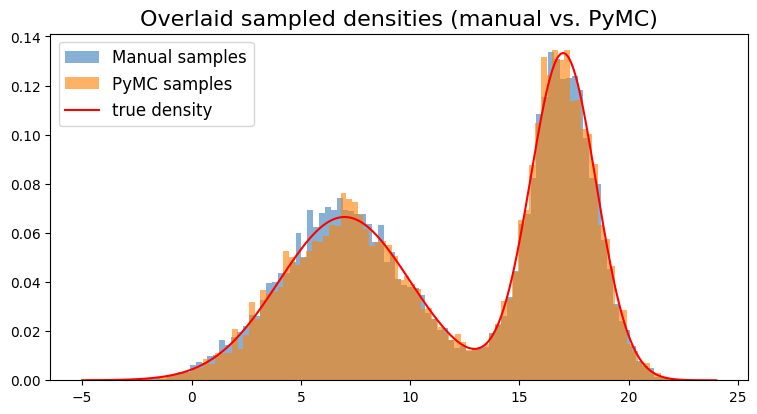

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
py_samples = trace.posterior["x"].values.flatten()
ax.hist(samples_post_burnin, bins=100, density=True, alpha=0.6, label="Manual samples", color='#377eb8')
ax.hist(py_samples, bins=100, density=True, alpha=0.6, label="PyMC samples", color='#ff7f00')
xs = np.linspace(-5, 24, 500)
ax.plot(xs, true_density(xs), "r-", lw=1.5, label="true density", color='red')
ax.legend(fontsize=12)
ax.set_title('Overlaid sampled densities (manual vs. PyMC)', fontsize=16)

plt.show()

In [ ]:
true_mean = 0.5 * 7 + 0.5 * 17  # = 0.5
print("True mean:", true_mean)
print("Manual mean:",round(samples_post_burnin.mean(), 2))
print("PyMC mean:",round(py_samples.mean(), 2))

True mean: 12.0
Manual mean: 11.8
PyMC mean: 12.05


In [ ]:
# Run the sampler
rng = np.random.default_rng(seed=42)
samples, accept_rate = metropolis_hastings(
    log_target_bimodal, x0=0.0, n_iter=50_000, proposal_sigma=2.0, rng=rng
)

# Discard burn-in
samples = samples[5000:]


print(f"Mean:     {samples.mean():.3f}")
print(f"Std dev:  {samples.std():.3f}")
print(f"Variance: {samples.var():.3f}")
print(f"Median:   {np.median(samples):.3f}")
print(f"Min:      {samples.min():.3f}")
print(f"Max:      {samples.max():.3f}")
print(f"2.5%:     {np.percentile(samples, 2.5):.3f}")
print(f"97.5%:    {np.percentile(samples, 97.5):.3f}")


print(f"\nTrue mean: {true_mean:.3f}")

Mean:     11.807
Std dev:  5.621
Variance: 31.599
Median:   12.711
Min:      -4.602
Max:      22.517
2.5%:     1.776
97.5%:    19.430

True mean: 12.000


In [ ]:
samples = trace.posterior["x"].values.flatten()

# Summary statistics
print(f"Mean:     {samples.mean():.3f}")
print(f"Std dev:  {samples.std():.3f}")
print(f"Variance: {samples.var():.3f}")
print(f"Median:   {np.median(samples):.3f}")
print(f"Min:      {samples.min():.3f}")
print(f"Max:      {samples.max():.3f}")
print(f"2.5%:     {np.percentile(samples, 2.5):.3f}")
print(f"97.5%:    {np.percentile(samples, 97.5):.3f}")

print(f"\nTrue mean: {true_mean:.3f}")


print("\n--- ArviZ summary ---")
print(az.summary(trace, var_names=["x"]))

Shape validation failed: input_shape: (1, 45000), minimum_shape: (chains=2, draws=4)


Mean:     12.052
Std dev:  5.515
Variance: 30.417
Median:   13.904
Min:      -3.393
Max:      22.786
2.5%:     2.131
97.5%:    19.507

True mean: 12.000

--- ArviZ summary ---
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x  12.052  5.515   2.675   19.472      0.066    0.022    7789.0   10596.0   

   r_hat  
x    NaN  


Shape validation failed: input_shape: (1, 10000), minimum_shape: (chains=2, draws=4)



Total samples, 1 chain:  10000
Total samples, 5 chains: 50000

R-hat (5 chains): 1.000
R-hat (1 chain):  cannot be computed -- convergence cannot be checked this way with a single chain

ESS (1 chain):  1581
ESS (5 chains): 7741


/tmp/ipykernel_1331/3346859314.py:48: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(xs, true_density(xs), "k-", lw=2, label="true density", color="red")


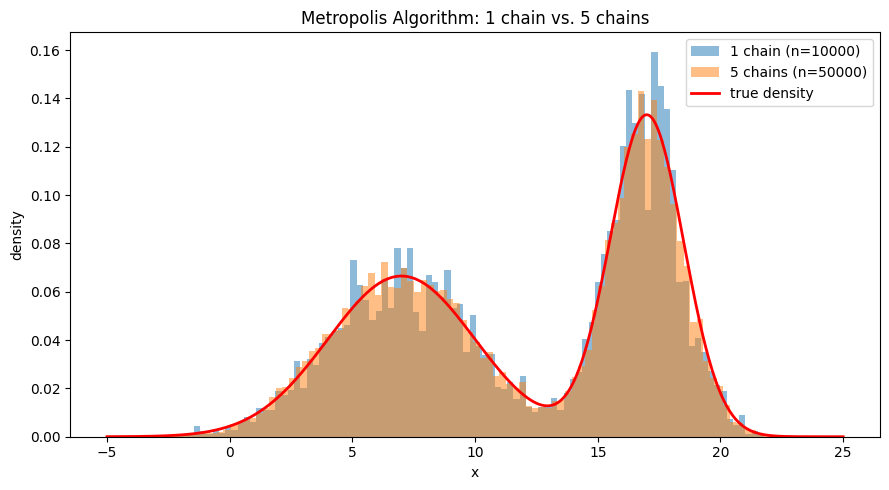

In [ ]:
def run_sampler(n_chains, seed=42):
    with pm.Model():
        w = pt.as_tensor([0.5, 0.5])
        mu = pt.as_tensor([7.0, 17.0])
        sigma = pt.as_tensor([3.0, 1.5])

        x = pm.NormalMixture("x", w=w, mu=mu, sigma=sigma)

        step = pm.Metropolis(vars=[x], scaling=2.0)
        trace = pm.sample(
            draws=10_000, tune=2_000, step=step,
            chains=n_chains, cores=1,
            initvals={"x": 0.0},
            random_seed=seed, progressbar=False,
        )
    return trace

trace_1 = run_sampler(n_chains=1)

trace_5 = run_sampler(n_chains=5)

samples_1 = trace_1.posterior["x"].values.flatten()
samples_5 = trace_5.posterior["x"].values.flatten()

print(f"\nTotal samples, 1 chain:  {len(samples_1)}")
print(f"Total samples, 5 chains: {len(samples_5)}")


summary_5 = az.summary(trace_5, var_names=["x"])

print(f"\nESS (1 chain):  {az.summary(trace_1, var_names=['x'])['ess_bulk'].values[0]:.0f}")
print(f"ESS (5 chains): {summary_5['ess_bulk'].values[0]:.0f}")

fig, ax = plt.subplots(figsize=(9, 5))
xs = np.linspace(-5, 25, 500)

ax.hist(samples_1, bins=100, density=True, alpha=0.5,
        label=f"1 chain (n={len(samples_1)})", color="tab:blue")
ax.hist(samples_5, bins=100, density=True, alpha=0.5,
        label=f"5 chains (n={len(samples_5)})", color="tab:orange")
ax.plot(xs, true_density(xs), "k-", lw=2, label="true density", color="red")

ax.set_xlabel("x")
ax.set_ylabel("density")
ax.set_title("Metropolis Algorithm: 1 chain vs. 5 chains")
ax.legend()
plt.tight_layout()